# Custom Visibility Functions

The base `VisibilityFunction` uses a **small-spot approximation** where the projected area of a spot simplifies to

$$A(t) \approx \pi\,\alpha^2\,\cos\beta(t)$$

which allows closed-form Fourier coefficients $c_n(I, \Phi)$. This is accurate when the spot angular radius $\alpha_{\max} \lesssim 6°$ (typical for Sun-like stars), but breaks down for large spots.

This notebook demonstrates how to subclass `VisibilityFunction` to implement the **exact piecewise projected area** from Eq. 5 of Birky et al., and finds where the small-spot approximation begins to diverge.

In [1]:
import sys
sys.path.append("../..")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from spotgp import (
    VisibilityFunction,
    FullGeometryVisibilityFunction,
    TrapezoidSymmetricEnvelope,
    SpotEvolutionModel,
    AnalyticKernel,
)

plt.rcParams.update({                                                                                  
    "font.size":        16,   # base font size                                                         
    "axes.titlesize":   20,   # axes title                                                             
    "axes.labelsize":   18,   # x/y axis labels                                                        
    "xtick.labelsize":  14,   # x tick labels                                                          
    "ytick.labelsize":  14,   # y tick labels                                                          
    "legend.fontsize":  14,                                                                            
    "figure.titlesize": 22,   # suptitle
    "axes.formatter.useoffset": False,  # disable scientific notation offset                                                   
})   

---
## 1. The exact projected area 

```{admonition} The full equation

The projected area of a circular spot with angular radius $\alpha$ at angle $\beta$ from the line of sight has three geometric regimes:

$$
A_k(t) = \begin{cases}
\pi \sin^2 \alpha_k \cos \beta_k & (0 < \beta_k < \pi/2 - \alpha_k) \\
\cos^{-1}[\cos \alpha_k \csc \beta_k] + \cos \beta_k \sin^2 \alpha_k \cos^{-1}[-\cot \alpha_k \cot \beta_k] \\
\quad - \cos \alpha_k \sin \beta_k \sqrt{1 - \cos^2 \alpha_k \csc^2 \beta_k} & (\pi/2 - \alpha_k < \beta_k < \pi/2 + \alpha_k) \\
0 & (\pi/2 + \alpha_k < \beta_k < \pi)
\end{cases}
$$
```
    
where $\beta_k$ is the angle between the spot normal and the line of sight:

$$\cos\beta(t) = \cos I \sin \Phi + \sin I \cos \Phi \cos \Lambda(t)$$

The three cases correspond to:
- **Fully visible**: the entire spot disk is on the near hemisphere
- **Partially visible**: the spot straddles the stellar limb
- **Hidden**: the spot is on the far side

---
## 2. Implementing a custom `VisibilityFunction`

To create a custom visibility function, subclass `VisibilityFunction` and override `cn_squared()`. The key methods to implement are:

| Method | Purpose |
|---|---|
| `projected_area(alpha, beta)` | Compute projected area for given spot size and angle |
| `cos_beta(phi, longitude)` | Angle between spot normal and line of sight |
| `cn_squared(phi, n_harmonics)` | Squared Fourier coefficients (override base class) |

Here is the implementation of `FullGeometryVisibilityFunction` (which can be found in [visibility.py](https://github.com/jbirky/spotgp/tree/main/src/visibility.py))

In [2]:
class FullGeometryVisibilityFunction(VisibilityFunction):
    """
    Exact projected spot area using the full piecewise geometry,
    without the small-spot approximation.
    """

    def __init__(self, peq, kappa, inc, alpha_ref=0.1, n_lon=512):
        super().__init__(peq=peq, kappa=kappa, inc=inc)
        self.alpha_ref = float(alpha_ref)
        self.n_lon = int(n_lon)

    @staticmethod
    def projected_area(alpha, beta):
        """Exact projected area A(alpha, beta) — Eq. 5."""
        alpha = jnp.asarray(alpha)
        beta = jnp.asarray(beta)

        cos_a, sin_a = jnp.cos(alpha), jnp.sin(alpha)
        cos_b, sin_b = jnp.cos(beta), jnp.sin(beta)

        eps = 1e-30
        csc_b = 1.0 / (sin_b + eps)
        cot_b = cos_b / (sin_b + eps)
        cot_a = cos_a / (sin_a + eps)

        # Case 1: fully visible
        A_full = jnp.pi * sin_a**2 * cos_b

        # Case 2: partially visible
        arg1 = jnp.clip(cos_a * csc_b, -1.0, 1.0)
        arg2 = jnp.clip(-cot_a * cot_b, -1.0, 1.0)
        sqrt_arg = jnp.clip(1.0 - cos_a**2 * csc_b**2, 0.0, None)

        A_partial = (jnp.arccos(arg1)
                     + cos_b * sin_a**2 * jnp.arccos(arg2)
                     - cos_a * sin_b * jnp.sqrt(sqrt_arg))

        # Select case
        half_pi = jnp.pi / 2.0
        A = jnp.where(beta < half_pi - alpha, A_full,
                      jnp.where(beta > half_pi + alpha, 0.0, A_partial))
        return jnp.where(alpha > 1e-15, A, 0.0)

    def cos_beta(self, phi, longitude):
        """cos(beta) from Eq. 6."""
        return (jnp.cos(self.inc) * jnp.sin(phi)
                + jnp.sin(self.inc) * jnp.cos(phi) * jnp.cos(longitude))

    def cn_squared(self, phi, n_harmonics=3):
        """Fourier coefficients via numerical DFT of exact area profile."""
        lon = jnp.linspace(0, 2 * jnp.pi, self.n_lon, endpoint=False)
        cos_b = self.cos_beta(phi, lon)
        beta = jnp.arccos(jnp.clip(cos_b, -1.0, 1.0))
        A = self.projected_area(self.alpha_ref, beta)

        norm = jnp.pi * jnp.sin(self.alpha_ref)**2
        A_norm = A / jnp.where(norm > 1e-30, norm, 1.0)

        fft_coeffs = jnp.fft.rfft(A_norm) / len(A_norm)
        cn = jnp.abs(fft_coeffs[:n_harmonics + 1])
        return cn**2

---
## 3. Visualize the projected area

First, we show the size of spots with different angular radii $\alpha_{\max}$ on the stellar disk at $\beta = 0$ (disk center). Then we compare the exact projected area to the small-spot approximation as a function of $\beta$.

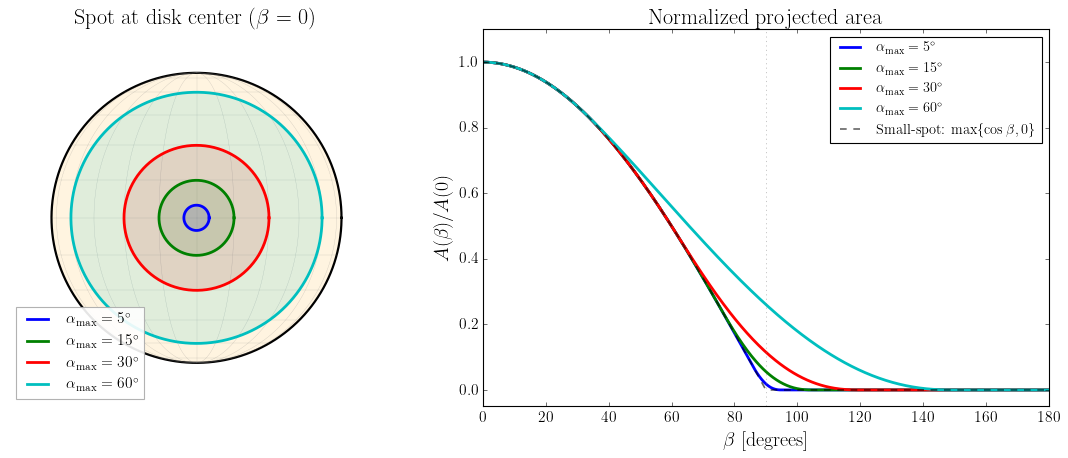

In [3]:
# Spot sizes on the stellar disk at beta=0 (disk center)
alphas_deg = [5, 15, 30, 60]
colors_disk = ['C0', 'C1', 'C2', 'C3']

fig, (ax_disk, ax_area) = plt.subplots(1, 2, figsize=(14, 6),
                                        gridspec_kw={'width_ratios': [1, 1.3]})

# -- Left: stellar disk with spots at disk center --
th = np.linspace(0, 2 * np.pi, 500)
ax_disk.plot(np.cos(th), np.sin(th), 'k-', lw=2)
ax_disk.fill(np.cos(th), np.sin(th), color='#FFF4E0', zorder=0)

# Latitude/longitude grid
for lat_deg in np.arange(-75, 90, 15):
    lat = np.radians(lat_deg)
    lon = np.linspace(-np.pi / 2, np.pi / 2, 500)
    y_proj = np.cos(lat) * np.sin(lon)
    z_proj = np.sin(lat)
    ax_disk.plot(y_proj, np.full_like(y_proj, z_proj),
                 color='gray', lw=0.3, alpha=0.4)
for lon_deg in np.arange(-75, 90, 15):
    lon = np.radians(lon_deg)
    lat = np.linspace(-np.pi / 2, np.pi / 2, 500)
    y_proj = np.cos(lat) * np.sin(lon)
    z_proj = np.sin(lat)
    ax_disk.plot(y_proj, z_proj, color='gray', lw=0.3, alpha=0.4)

# Draw spot circles at disk center
for alpha_deg, color in zip(alphas_deg, colors_disk):
    alpha = np.radians(alpha_deg)
    r_spot = np.sin(alpha)  # projected radius on the unit disk
    spot_th = np.linspace(0, 2 * np.pi, 300)
    ax_disk.plot(r_spot * np.cos(spot_th), r_spot * np.sin(spot_th),
                 color=color, lw=2.5,
                 label=rf'$\alpha_{{\max}} = {alpha_deg}^\circ$', zorder=3)
    ax_disk.fill(r_spot * np.cos(spot_th), r_spot * np.sin(spot_th),
                 color=color, alpha=0.12, zorder=2)

ax_disk.set_xlim(-1.3, 1.3)
ax_disk.set_ylim(-1.3, 1.3)
ax_disk.set_aspect('equal')
ax_disk.set_title(r'Spot at disk center ($\beta = 0$)')
ax_disk.legend(loc='lower left', framealpha=0.9, edgecolor='#AAAAAA')
ax_disk.axis('off')

# -- Right: normalized projected area A(beta)/A(0) vs beta --
beta = np.linspace(0, np.pi, 500)
for alpha_deg, color in zip(alphas_deg, colors_disk):
    alpha = np.radians(alpha_deg)
    A_exact = np.array(FullGeometryVisibilityFunction.projected_area(alpha, jnp.array(beta)))
    A_max = np.pi * np.sin(alpha)**2
    ax_area.plot(np.degrees(beta), A_exact / A_max,
                 color=color, lw=2.5,
                 label=rf'$\alpha_{{\max}} = {alpha_deg}^\circ$')

# Small-spot approximation
ax_area.plot(np.degrees(beta), np.maximum(np.cos(beta), 0),
             'k--', lw=1.5, alpha=0.6,
             label=r'Small-spot: $\max\{\cos\beta, 0\}$')

ax_area.axvline(90, color='gray', ls=':', lw=0.8, alpha=0.5)
ax_area.set_xlabel(r'$\beta$ [degrees]')
ax_area.set_ylabel(r'$A(\beta) / A(0)$')
ax_area.set_title('Normalized projected area')
ax_area.legend(fontsize=13, loc='upper right')
ax_area.set_xlim(0, 180)
ax_area.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

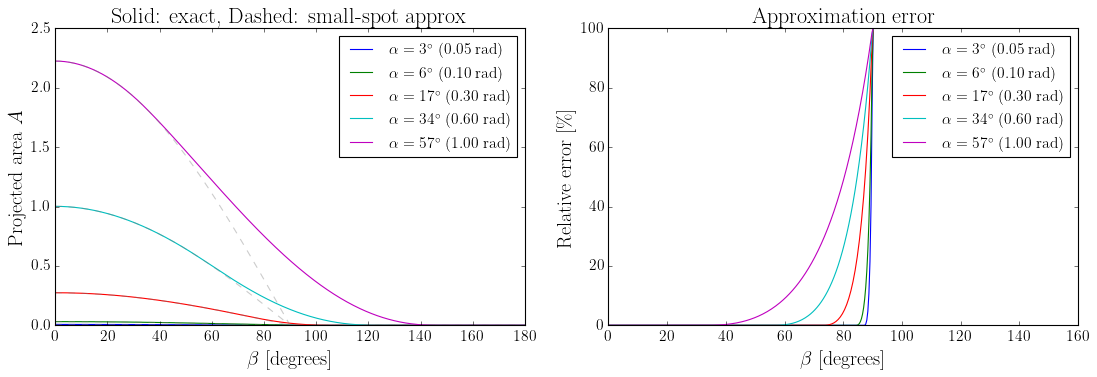

In [4]:
beta = jnp.linspace(0, jnp.pi, 500)
alphas = [0.05, 0.1, 0.3, 0.6, 1.0]  # radians

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for alpha in alphas:
    A_exact = np.array(FullGeometryVisibilityFunction.projected_area(alpha, beta))
    A_approx = np.pi * np.sin(alpha)**2 * np.clip(np.cos(beta), 0, None)

    label = rf"$\alpha = {np.degrees(alpha):.0f}^\circ$ ({alpha:.2f} rad)"
    axes[0].plot(np.degrees(np.array(beta)), A_exact, label=label)
    axes[0].plot(np.degrees(np.array(beta)), A_approx, "--", color="gray", alpha=0.4)

    # Relative error (avoid division by zero)
    mask = A_exact > 1e-10
    rel_err = np.full_like(A_exact, np.nan)
    rel_err[mask] = np.abs(A_exact[mask] - A_approx[mask]) / A_exact[mask]
    axes[1].plot(np.degrees(np.array(beta)), rel_err * 100, label=label)

axes[0].set_xlabel(r"$\beta$ [degrees]")
axes[0].set_ylabel(r"Projected area $A$")
axes[0].set_title("Solid: exact, Dashed: small-spot approx")
axes[0].legend()

axes[1].set_xlabel(r"$\beta$ [degrees]")
axes[1].set_ylabel(r"Relative error [\%]")
axes[1].set_title("Approximation error")
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.show()

The small-spot approximation is accurate for the fully visible region but completely misses the partial-visibility transition near the limb ($\beta \approx 90°$). For small spots ($\alpha \lesssim 6°$), the partial-visibility window is so narrow that this error is negligible; for large spots, the smooth transition matters.

---
## 4. Compare Fourier coefficients $|c_n|^2$

The analytic kernel depends on the squared Fourier coefficients $|c_n|^2$. Compare the closed-form (small-spot) coefficients to the numerically computed (exact geometry) coefficients as a function of spot size.

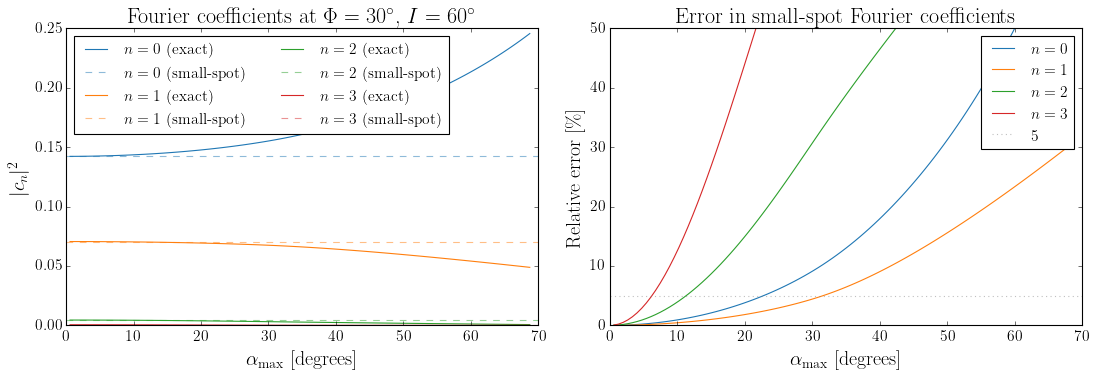

In [5]:
inc = np.pi / 3
phi = np.pi / 6  # 30 deg latitude
n_harmonics = 3

alpha_grid = np.linspace(0.01, 1.2, 100)  # 0.6 deg to 69 deg

cn_small_spot = np.array([
    VisibilityFunction(peq=10.0, kappa=0.0, inc=inc).cn_squared(phi, n_harmonics)
    for _ in alpha_grid
])  # shape (n_alpha, n_harmonics+1) — independent of alpha

cn_exact = np.array([
    FullGeometryVisibilityFunction(
        peq=10.0, kappa=0.0, inc=inc, alpha_ref=a
    ).cn_squared(phi, n_harmonics)
    for a in alpha_grid
])  # shape (n_alpha, n_harmonics+1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10.colors

for n in range(n_harmonics + 1):
    axes[0].plot(np.degrees(alpha_grid), cn_exact[:, n],
                 color=colors[n], label=f"$n={n}$ (exact)")
    axes[0].axhline(cn_small_spot[0, n], color=colors[n], ls="--", alpha=0.5,
                    label=f"$n={n}$ (small-spot)")

axes[0].set_xlabel(r"$\alpha_{\max}$ [degrees]")
axes[0].set_ylabel(r"$|c_n|^2$")
axes[0].set_title(rf"Fourier coefficients at $\Phi = {np.degrees(phi):.0f}^\circ$, $I = {np.degrees(inc):.0f}^\circ$")
axes[0].legend(fontsize=14, ncol=2, loc="upper left")

# Relative error in each coefficient
for n in range(n_harmonics + 1):
    ref = cn_small_spot[0, n]
    if ref > 1e-15:
        rel_err = np.abs(cn_exact[:, n] - ref) / ref * 100
        axes[1].plot(np.degrees(alpha_grid), rel_err,
                     color=colors[n], label=f"$n={n}$")

axes[1].axhline(5, color="gray", ls=":", alpha=0.5, label="5% threshold")
axes[1].set_xlabel(r"$\alpha_{\max}$ [degrees]")
axes[1].set_ylabel(r"Relative error [\%]")
axes[1].set_title("Error in small-spot Fourier coefficients")
axes[1].legend()
axes[1].set_ylim(0, 50)

plt.tight_layout()
plt.show()

---
## 5. Divergence threshold: where does the approximation break down?

Find the spot size $\alpha_{\max}$ at which the small-spot Fourier coefficients deviate from the exact values by more than 5%, as a function of inclination.

<>:32: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:32: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/tmp/ipykernel_2695030/726072386.py:32: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  ax.set_ylabel("Max relative error in $|c_n|^2$ [\%]")


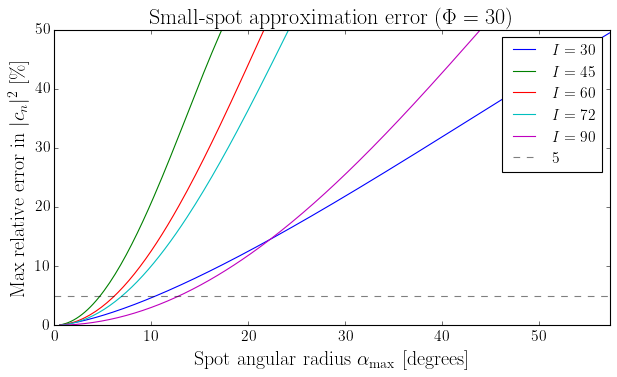

In [6]:
alpha_fine = np.linspace(0.01, 1.0, 200)
inclinations = np.array([np.pi / 6, np.pi / 4, np.pi / 3, np.pi / 2.5, np.pi / 2])
phi_test = np.pi / 6
threshold = 0.05  # 5%

fig, ax = plt.subplots(figsize=(8, 5))

for inc in inclinations:
    cn_ref = np.array(
        VisibilityFunction(peq=10.0, kappa=0.0, inc=inc).cn_squared(phi_test, 3)
    )

    cn_ex = np.array([
        FullGeometryVisibilityFunction(
            peq=10.0, kappa=0.0, inc=inc, alpha_ref=a
        ).cn_squared(phi_test, 3)
        for a in alpha_fine
    ])

    # Max relative error across all harmonics with nonzero reference
    nonzero = cn_ref > 1e-15
    max_rel_err = np.max(
        np.abs(cn_ex[:, nonzero] - cn_ref[nonzero]) / cn_ref[nonzero],
        axis=1,
    )

    ax.plot(np.degrees(alpha_fine), max_rel_err * 100,
            label=rf"$I = {np.degrees(inc):.0f}°$")

ax.axhline(threshold * 100, color="k", ls="--", alpha=0.5, label=f"{threshold*100:.0f}% threshold")
ax.set_xlabel(r"Spot angular radius $\alpha_{\max}$ [degrees]")
ax.set_ylabel("Max relative error in $|c_n|^2$ [\%]")
ax.set_title(rf"Small-spot approximation error ($\Phi = {np.degrees(phi_test):.0f}°$)")
ax.legend()
ax.set_ylim(0, 50)
ax.set_xlim(0, np.degrees(alpha_fine[-1]))
plt.tight_layout()
plt.show()

In [7]:
print(f"{'Inclination':>14s}  {'alpha_max (5% threshold)':>26s}")
print("-" * 44)

for inc in inclinations:
    cn_ref = np.array(
        VisibilityFunction(peq=10.0, kappa=0.0, inc=inc).cn_squared(phi_test, 3)
    )
    cn_ex = np.array([
        FullGeometryVisibilityFunction(
            peq=10.0, kappa=0.0, inc=inc, alpha_ref=a
        ).cn_squared(phi_test, 3)
        for a in alpha_fine
    ])

    nonzero = cn_ref > 1e-15
    max_rel_err = np.max(
        np.abs(cn_ex[:, nonzero] - cn_ref[nonzero]) / cn_ref[nonzero],
        axis=1,
    )

    idx = np.argmax(max_rel_err > threshold)
    if max_rel_err[idx] > threshold:
        alpha_thresh = np.degrees(alpha_fine[idx])
        print(f"{np.degrees(inc):>12.0f}°  {alpha_thresh:>22.1f}°")
    else:
        print(f"{np.degrees(inc):>12.0f}°  {'> 57°':>22s}")

   Inclination    alpha_max (5% threshold)
--------------------------------------------
          30°                    10.5°
          45°                     4.8°
          60°                     6.3°
          72°                     7.1°
          90°                    13.1°


---
## 6. Compare GP kernels

Build an `AnalyticKernel` with each visibility function and compare the resulting covariance kernels.

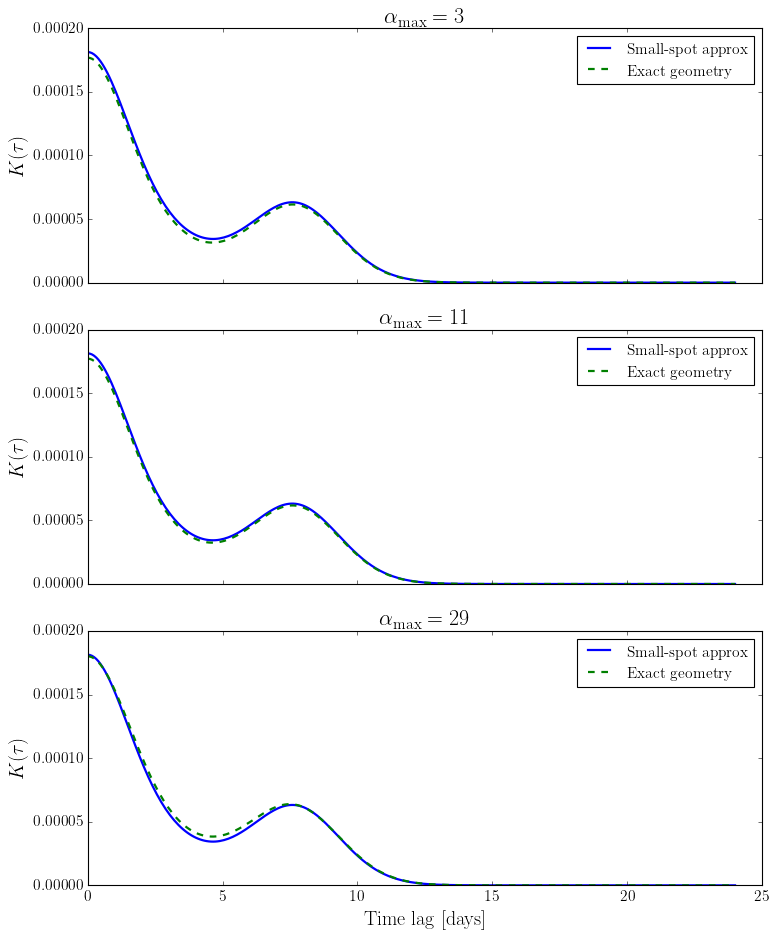

In [8]:
env = TrapezoidSymmetricEnvelope(lspot=10.0, tau_spot=3.0)
peq, kappa, inc = 8.0, 0.2, np.pi / 3

alphas_compare = [0.05, 0.2, 0.5]
lag = np.linspace(0, 3 * peq, 300)

fig, axes = plt.subplots(len(alphas_compare), 1, figsize=(10, 4 * len(alphas_compare)),
                         sharex=True)

for ax, alpha in zip(axes, alphas_compare):
    # Small-spot kernel
    vis_small = VisibilityFunction(peq=peq, kappa=kappa, inc=inc)
    model_small = SpotEvolutionModel(envelope=env, visibility=vis_small, sigma_k=0.01)
    K_small = AnalyticKernel(model_small).kernel(lag)

    # Full geometry kernel
    vis_full = FullGeometryVisibilityFunction(
        peq=peq, kappa=kappa, inc=inc, alpha_ref=alpha)
    model_full = SpotEvolutionModel(envelope=env, visibility=vis_full, sigma_k=0.01)
    K_full = AnalyticKernel(model_full).kernel(lag)

    ax.plot(lag, np.array(K_small), label="Small-spot approx", lw=2)
    ax.plot(lag, np.array(K_full), "--", label="Exact geometry", lw=2)
    ax.set_ylabel(r"$K(\tau)$")
    ax.set_title(rf"$\alpha_{{\max}} = {np.degrees(alpha):.0f}°$")
    ax.legend()

axes[-1].set_xlabel("Time lag [days]")
plt.tight_layout()
plt.show()

---
## 7. Computation speed comparison

The small-spot approximation uses closed-form Fourier coefficients $c_n(I, \Phi)$, while the full geometry computes them numerically via DFT at each latitude. How much does this cost in practice?

We benchmark three operations:
1. **`cn_squared`** — computing the Fourier coefficients at a single latitude
2. **`AnalyticKernel.kernel()`** — full kernel evaluation (latitude-averaged) on a lag array
3. **`GPSolver.log_posterior()`** — full log-likelihood evaluation (kernel + Cholesky + solve)

In [9]:
import time
import jax
from spotgp import GPSolver

jax.config.update("jax_enable_x64", True)

env = TrapezoidSymmetricEnvelope(lspot=10.0, tau_spot=3.0)
peq, kappa, inc = 8.0, 0.0, np.pi / 3
n_harmonics = 3
phi_test = np.pi / 6

vis_small = VisibilityFunction(peq=peq, kappa=kappa, inc=inc)
vis_full = FullGeometryVisibilityFunction(peq=peq, kappa=kappa, inc=inc, alpha_ref=0.1)

# --- 1. cn_squared benchmark ---
n_repeat = 200

# Warmup
_ = vis_small.cn_squared(phi_test, n_harmonics)
_ = vis_full.cn_squared(phi_test, n_harmonics)

t0 = time.perf_counter()
for _ in range(n_repeat):
    _ = vis_small.cn_squared(phi_test, n_harmonics)
t_cn_small = (time.perf_counter() - t0) / n_repeat

t0 = time.perf_counter()
for _ in range(n_repeat):
    _ = vis_full.cn_squared(phi_test, n_harmonics)
t_cn_full = (time.perf_counter() - t0) / n_repeat

print("=== cn_squared (single latitude) ===")
print(f"  Small-spot:     {t_cn_small*1e3:.3f} ms")
print(f"  Full geometry:  {t_cn_full*1e3:.3f} ms")
print(f"  Slowdown:       {t_cn_full/t_cn_small:.1f}x")

# --- 2. AnalyticKernel.kernel() benchmark ---
lag = np.linspace(0, 3 * peq, 500)

model_small = SpotEvolutionModel(envelope=env, visibility=vis_small, sigma_k=0.01)
model_full = SpotEvolutionModel(envelope=env, visibility=vis_full, sigma_k=0.01)

ak_small = AnalyticKernel(model_small, n_harmonics=n_harmonics)
ak_full = AnalyticKernel(model_full, n_harmonics=n_harmonics)

# Warmup
_ = ak_small.kernel(lag)
_ = ak_full.kernel(lag)

n_repeat_k = 20

t0 = time.perf_counter()
for _ in range(n_repeat_k):
    _ = ak_small.kernel(lag)
t_k_small = (time.perf_counter() - t0) / n_repeat_k

t0 = time.perf_counter()
for _ in range(n_repeat_k):
    _ = ak_full.kernel(lag)
t_k_full = (time.perf_counter() - t0) / n_repeat_k

print(f"\n=== AnalyticKernel.kernel() ({len(lag)} lags) ===")
print(f"  Small-spot:     {t_k_small*1e3:.1f} ms")
print(f"  Full geometry:  {t_k_full*1e3:.1f} ms")
print(f"  Slowdown:       {t_k_full/t_k_small:.1f}x")

# --- 3. GPSolver.log_posterior() benchmark ---
tsim_values = [100, 500, 1000]
tsamp = 0.5
sigma_n = 1e-3
n_repeat_gp = 5

print(f"\n=== GPSolver.log_posterior() (banded Cholesky) ===")
print(f"{'N':>8s}  {'Small-spot':>12s}  {'Full geom.':>12s}  {'Slowdown':>10s}")
print("-" * 48)

for tsim in tsim_values:
    x_obs = np.arange(0, tsim, tsamp)
    N = len(x_obs)
    y_obs = np.zeros(N)
    yerr_obs = np.full(N, sigma_n)

    hparam = dict(peq=peq, kappa=kappa, inc=inc, lspot=10.0, tau=3.0, sigma_k=0.01)

    # Small-spot solver
    gp_s = GPSolver(x_obs, y_obs, yerr_obs, model_small,
                    matrix_solver="cholesky_banded", fit_sigma_n=False,
                    n_harmonics=n_harmonics)
    theta_s = gp_s.theta0
    # Warmup
    for _ in range(2):
        _ = gp_s.log_posterior(theta_s).block_until_ready()
    t0 = time.perf_counter()
    for _ in range(n_repeat_gp):
        _ = gp_s.log_posterior(theta_s).block_until_ready()
    t_gp_small = (time.perf_counter() - t0) / n_repeat_gp

    # Full geometry solver
    gp_f = GPSolver(x_obs, y_obs, yerr_obs, model_full,
                    matrix_solver="cholesky_banded", fit_sigma_n=False,
                    n_harmonics=n_harmonics)
    theta_f = gp_f.theta0
    for _ in range(2):
        _ = gp_f.log_posterior(theta_f).block_until_ready()
    t0 = time.perf_counter()
    for _ in range(n_repeat_gp):
        _ = gp_f.log_posterior(theta_f).block_until_ready()
    t_gp_full = (time.perf_counter() - t0) / n_repeat_gp

    print(f"{N:>8d}  {t_gp_small*1e3:>10.1f} ms  {t_gp_full*1e3:>10.1f} ms  {t_gp_full/t_gp_small:>8.1f}x")

=== cn_squared (single latitude) ===
  Small-spot:     0.339 ms
  Full geometry:  1.041 ms
  Slowdown:       3.1x

=== AnalyticKernel.kernel() (500 lags) ===
  Small-spot:     89.0 ms
  Full geometry:  80.9 ms
  Slowdown:       0.9x

=== GPSolver.log_posterior() (banded Cholesky) ===
       N    Small-spot    Full geom.    Slowdown
------------------------------------------------
Banded Cholesky: bandwidth=80, N=200, sparsity=59.5%
Banded Cholesky: bandwidth=80, N=200, sparsity=59.5%
     200         6.4 ms         6.9 ms       1.1x
Banded Cholesky: bandwidth=80, N=1000, sparsity=91.9%
Banded Cholesky: bandwidth=80, N=1000, sparsity=91.9%
    1000        37.7 ms        36.7 ms       1.0x
Banded Cholesky: bandwidth=80, N=2000, sparsity=96.0%
Banded Cholesky: bandwidth=80, N=2000, sparsity=96.0%
    2000        90.0 ms        95.1 ms       1.1x


The `cn_squared` computation is significantly slower for the full geometry model because it evaluates the exact piecewise area function on a longitude grid and computes a DFT, whereas the small-spot approximation uses closed-form expressions. However, at the `GPSolver` level the difference is smaller because the Cholesky factorization dominates the total cost for large $N$. The kernel evaluation overhead from the full geometry becomes a smaller fraction of the total wall-clock time as the dataset grows.

---
## Summary

- The small-spot approximation ($A \approx \pi\alpha^2 \cos\beta$) is accurate for spot radii $\alpha_{\max} \lesssim 10\text{--}15°$, which covers the vast majority of observed starspots.
- For larger spots, the partial-visibility window near the stellar limb becomes significant, and the exact piecewise geometry should be used.
- To implement a custom visibility function, subclass `VisibilityFunction` and override `cn_squared()`. If the Fourier coefficients don't have a closed form, compute them numerically via DFT as shown above.
- The `FullGeometryVisibilityFunction` is available in `spotgp` as a built-in alternative to the base class.